In [ ]:
!pip install vaderSentiment textblob wordcloud -q
import nltk
nltk.download(['stopwords', 'punkt', 'wordnet', 'punkt_tab'])

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud
from collections import Counter
import statsmodels.formula.api as smf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.8 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Jawan_IMDB.csv")
df.head()

,web_scraper_order,web_scraper_start_url,Rate,Title,review,helpful,not helpful
0,1773141764-1,https://www.imdb.com/title/tt15354916/reviews/...,8/10,An Action-Packed Thriller with a Powerful Mess...,"Jawan, directed by Atlee, is a must-watch for ...",56,13
1,1773141764-2,https://www.imdb.com/title/tt15354916/reviews/...,8/10,An Action-Packed Thriller with a Social Consci...,"""Jawan"" is a dynamic action film that manages ...",47,13
2,1773141764-3,https://www.imdb.com/title/tt15354916/reviews/...,8/10,K & A,NaN,36,9
3,1773141764-4,https://www.imdb.com/title/tt15354916/reviews/...,10/10,must watch in theatre,This movie is really a must watch in theatre.\...,53,10
4,1773141764-5,https://www.imdb.com/title/tt15354916/reviews/...,7/10,7.7 - Unexpectedly good credit to Atlee,You can tell its directed by a South Indian bu...,78,45


In [ ]:
# Drop irrelevant columns
df = df.drop(columns=['web_scraper_order', 'web_scraper_start_url'])

# Drop rows where BOTH review AND rating are missing (useless rows)
df = df.dropna(subset=['review', 'Rate'], how='all')

# Drop rows with no review text (can't do NLP without text)
df = df.dropna(subset=['review'])

# Convert "8/10" → 8.0
df['rating'] = df['Rate'].str.extract(r'(\d+)').astype(float)
df = df.drop(columns=['Rate'])

# Reset index
df = df.reset_index(drop=True)

print(f"After cleaning: {df.shape[0]} reviews remaining")
print(df[['rating','review']].head(3))

After cleaning: 684 reviews remaining
   rating                                             review
0     8.0  Jawan, directed by Atlee, is a must-watch for ...
1     8.0  "Jawan" is a dynamic action film that manages ...
2    10.0  This movie is really a must watch in theatre.\...


In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Keep some sentiment words that stopwords removes by default
keep_words = {'not', 'no', 'never', 'but', 'however', 'very', 'too'}
stop_words = stop_words - keep_words

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)        # Remove URLs
    text = re.sub(r'<.*?>', '', text)                  # Remove HTML tags
    text = re.sub(r'[^a-z\s]', '', text)               # Keep only letters
    text = re.sub(r'\s+', ' ', text).strip()           # Extra whitespace
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df['cleaned_review'] = df['review'].apply(clean_text)

# Word count BEFORE cleaning (on original)
df['word_count'] = df['review'].apply(lambda x: len(str(x).split()))

print(df[['review', 'cleaned_review', 'word_count']].head(3))

                                              review  \
0  Jawan, directed by Atlee, is a must-watch for ...   
1  "Jawan" is a dynamic action film that manages ...   
2  This movie is really a must watch in theatre.\...   

                                      cleaned_review  word_count  
0  jawan directed atlee mustwatch fan shah rukh k...         261  
1  jawan dynamic action film manages pack punch a...         397  
2  movie really must watch theatre went little ex...         119  


In [ ]:
vader = SentimentIntensityAnalyzer()

# VADER scores (use on ORIGINAL review, not cleaned — VADER needs punctuation)
df['vader_compound']  = df['review'].apply(lambda x: vader.polarity_scores(str(x))['compound'])
df['vader_pos']       = df['review'].apply(lambda x: vader.polarity_scores(str(x))['pos'])
df['vader_neg']       = df['review'].apply(lambda x: vader.polarity_scores(str(x))['neg'])

# TextBlob polarity (use on cleaned review)
df['tb_polarity']     = df['cleaned_review'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['tb_subjectivity'] = df['cleaned_review'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

# Classify sentiment
def label_sentiment(score):
    if score >= 0.05:  return 'Positive'
    elif score <= -0.05: return 'Negative'
    else: return 'Neutral'

df['sentiment'] = df['vader_compound'].apply(label_sentiment)

print(df['sentiment'].value_counts())
print(df[['rating','vader_compound','tb_polarity','sentiment']].head())

sentiment
Positive    600
Negative     80
Neutral       4
Name: count, dtype: int64
   rating  vader_compound  tb_polarity sentiment
0     8.0          0.9389     0.289429  Positive
1     8.0          0.9973     0.180315  Positive
2    10.0          0.9769     0.324702  Positive
3     7.0          0.9639     0.178202  Positive
4    10.0          0.9945     0.161397  Positive


In [ ]:
df.to_csv("jawan_cleaned.csv", index=False)
print("✅ Saved! Final shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nSample:\n", df[['rating','word_count','vader_compound','sentiment']].describe())

✅ Saved! Final shape: (684, 13)

Columns: ['Title', 'review', 'helpful', 'not helpful', 'rating', 'cleaned_review', 'word_count', 'vader_compound', 'vader_pos', 'vader_neg', 'tb_polarity', 'tb_subjectivity', 'sentiment']

Missing values:
 Title              0
review             0
helpful            0
not helpful        0
rating             0
cleaned_review     0
word_count         0
vader_compound     0
vader_pos          0
vader_neg          0
tb_polarity        0
tb_subjectivity    0
sentiment          0
dtype: int64

Sample:
            rating  word_count  vader_compound
count  684.000000  684.000000      684.000000
mean     7.402047  162.364035        0.718466
std      3.135411   93.715656        0.556282
min      1.000000   64.000000       -0.996500
25%      6.000000  111.000000        0.852750
50%      9.000000  123.500000        0.971650
75%     10.000000  174.000000        0.988725
max     10.000000  682.000000        0.999300


In [ ]:
df.head()

,Title,review,helpful,not helpful,rating,cleaned_review,word_count,vader_compound,vader_pos,vader_neg,tb_polarity,tb_subjectivity,sentiment
0,An Action-Packed Thriller with a Powerful Mess...,"Jawan, directed by Atlee, is a must-watch for ...",56,13,8.0,jawan directed atlee mustwatch fan shah rukh k...,261,0.9389,0.160,0.094,0.289429,0.476095,Positive
1,An Action-Packed Thriller with a Social Consci...,"""Jawan"" is a dynamic action film that manages ...",47,13,8.0,jawan dynamic action film manages pack punch a...,397,0.9973,0.200,0.039,0.180315,0.458121,Positive
2,must watch in theatre,This movie is really a must watch in theatre.\...,53,10,10.0,movie really must watch theatre went little ex...,119,0.9769,0.187,0.018,0.324702,0.451190,Positive
3,7.7 - Unexpectedly good credit to Atlee,You can tell its directed by a South Indian bu...,78,45,7.0,tell directed south indian but thats make beau...,113,0.9639,0.244,0.114,0.178202,0.552747,Positive
4,"Peak entertainment, SRK in his massiest avatar","This is cinema, peak entertainment. Insane the...",51,11,10.0,cinema peak entertainment insane theatrical ci...,387,0.9945,0.186,0.068,0.161397,0.484030,Positive


=== SENTIMENT POLARITY SUMMARY ===

Mean VADER Compound Score: 0.7185
Std Dev: 0.5563
Range: -0.9965 to 0.9993


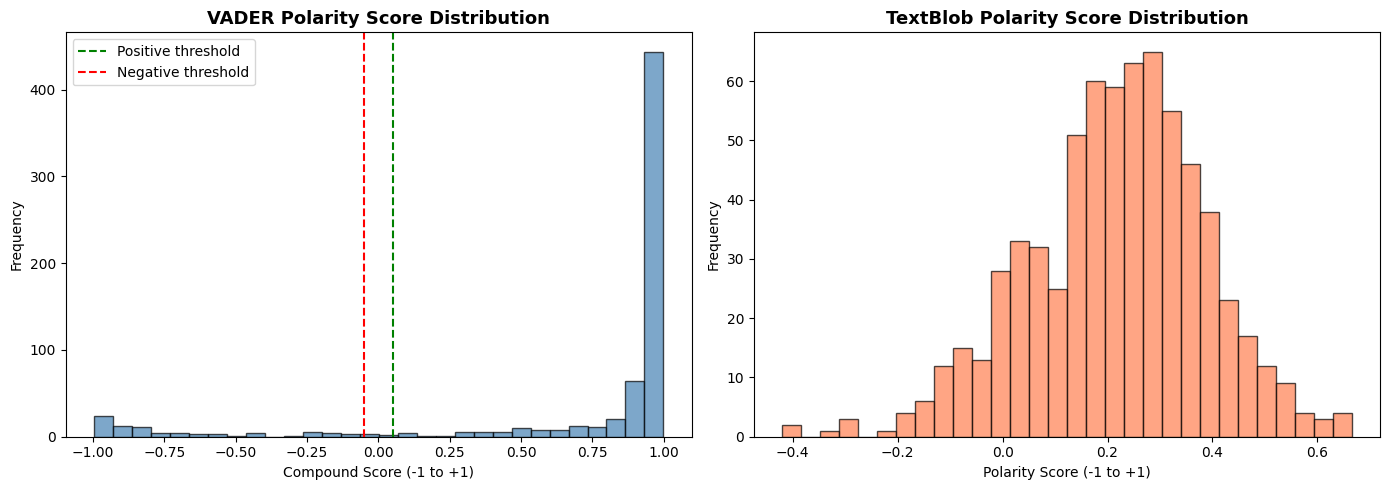


TextBlob Mean Polarity: 0.2170
TextBlob Mean Subjectivity: 0.5034


In [ ]:
# Your vader_compound IS the polarity score
# But let's also add TextBlob subjectivity as professor did

print("=== SENTIMENT POLARITY SUMMARY ===")
print(f"\nMean VADER Compound Score: {df['vader_compound'].mean():.4f}")
print(f"Std Dev: {df['vader_compound'].std():.4f}")
print(f"Range: {df['vader_compound'].min():.4f} to {df['vader_compound'].max():.4f}")

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['vader_compound'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0.05, color='green', linestyle='--', label='Positive threshold')
axes[0].axvline(x=-0.05, color='red', linestyle='--', label='Negative threshold')
axes[0].set_title('VADER Polarity Score Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Compound Score (-1 to +1)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(df['tb_polarity'], bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('TextBlob Polarity Score Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Polarity Score (-1 to +1)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('sentiment_polarity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTextBlob Mean Polarity: {df['tb_polarity'].mean():.4f}")
print(f"TextBlob Mean Subjectivity: {df['tb_subjectivity'].mean():.4f}")

=== REVIEW LENGTH ANALYSIS ===
count    684.000000
mean     162.364035
std       93.715656
min       64.000000
25%      111.000000
50%      123.500000
75%      174.000000
max      682.000000
Name: word_count, dtype: float64


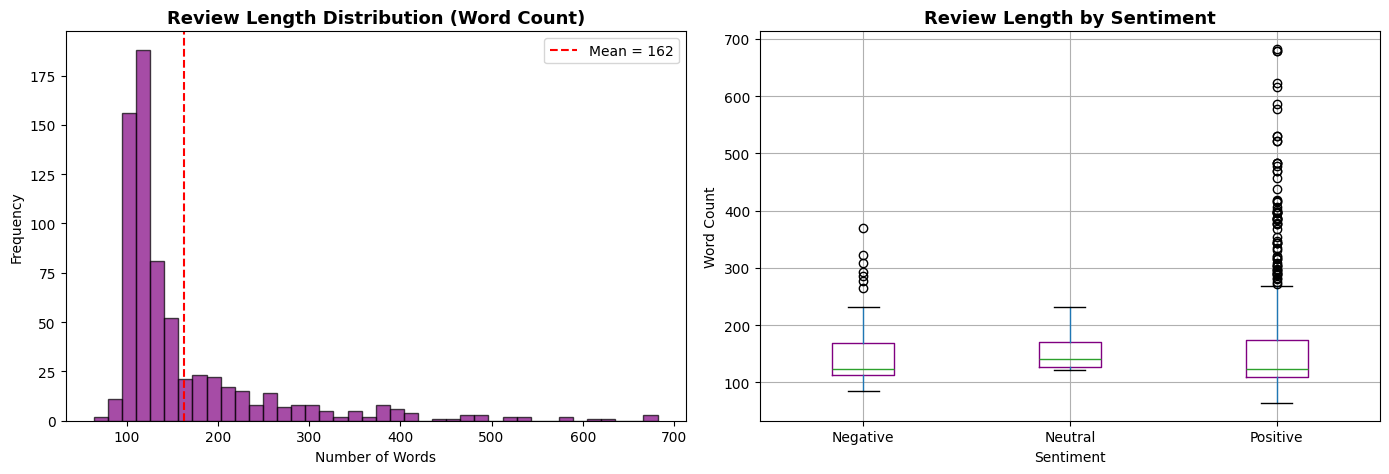


Word count by sentiment group:
                 mean  median  count
sentiment                           
Negative   151.112500   124.0     80
Neutral    158.000000   140.0      4
Positive   163.893333   123.0    600


In [ ]:
print("=== REVIEW LENGTH ANALYSIS ===")
print(df['word_count'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['word_count'], bins=40, color='purple', edgecolor='black', alpha=0.7)
axes[0].set_title('Review Length Distribution (Word Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['word_count'].mean(), color='red', linestyle='--',
                label=f"Mean = {df['word_count'].mean():.0f}")
axes[0].legend()

# By sentiment
df.boxplot(column='word_count', by='sentiment', ax=axes[1],
           boxprops=dict(color='purple'))
axes[1].set_title('Review Length by Sentiment', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Word Count')
plt.suptitle('')

plt.tight_layout()
plt.savefig('review_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Key stats by sentiment
print("\nWord count by sentiment group:")
print(df.groupby('sentiment')['word_count'].agg(['mean','median','count']))

=== RATING DISTRIBUTION ANALYSIS ===


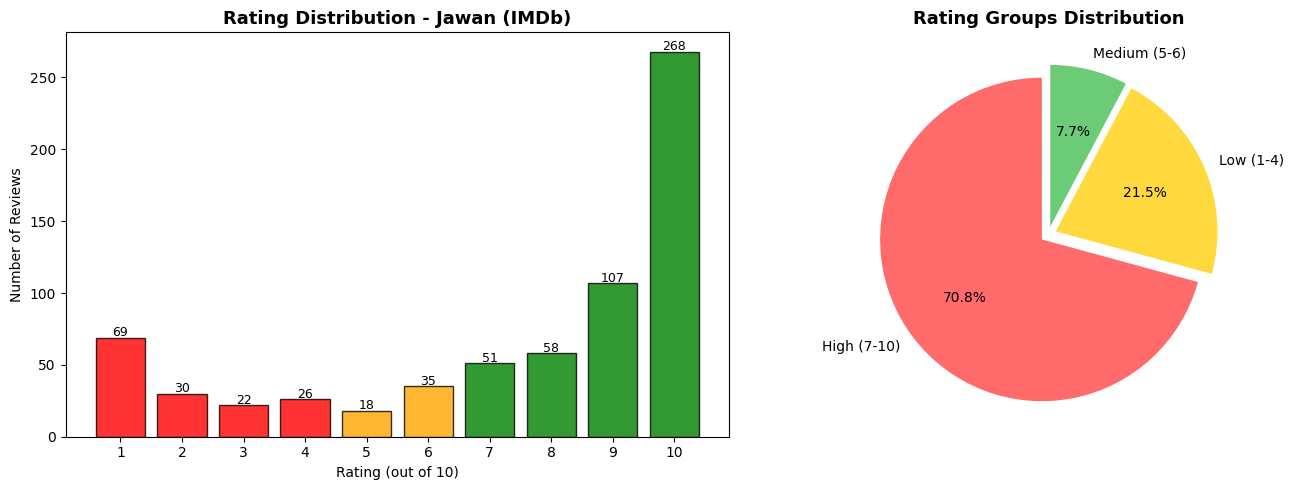


Mean Rating: 7.40
Median Rating: 9.00

Rating counts:
 rating
1.0      69
2.0      30
3.0      22
4.0      26
5.0      18
6.0      35
7.0      51
8.0      58
9.0     107
10.0    268
Name: count, dtype: int64

Rating group %:
 rating_group
High (7-10)     70.76
Low (1-4)       21.49
Medium (5-6)     7.75
Name: count, dtype: float64


In [ ]:
print("=== RATING DISTRIBUTION ANALYSIS ===")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
rating_counts = df['rating'].value_counts().sort_index()
colors = ['red' if r <= 4 else 'orange' if r <= 6 else 'green' for r in rating_counts.index]
axes[0].bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_title('Rating Distribution - Jawan (IMDb)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rating (out of 10)')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_xticks(range(1, 11))

# Add count labels on bars
for i, (rating, count) in enumerate(zip(rating_counts.index, rating_counts.values)):
    axes[0].text(rating, count + 1, str(count), ha='center', fontsize=9)

# Pie chart of rating groups
df['rating_group'] = pd.cut(df['rating'], bins=[0, 4, 6, 10],
                             labels=['Low (1-4)', 'Medium (5-6)', 'High (7-10)'])
group_counts = df['rating_group'].value_counts()
axes[1].pie(group_counts.values, labels=group_counts.index,
            autopct='%1.1f%%', colors=['#ff6b6b','#ffd93d','#6bcb77'],
            startangle=90, explode=[0.05, 0.05, 0.05])
axes[1].set_title('Rating Groups Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMean Rating: {df['rating'].mean():.2f}")
print(f"Median Rating: {df['rating'].median():.2f}")
print("\nRating counts:\n", rating_counts)
print("\nRating group %:\n", (group_counts / len(df) * 100).round(2))

=== SENTIMENT DISTRIBUTION ANALYSIS ===


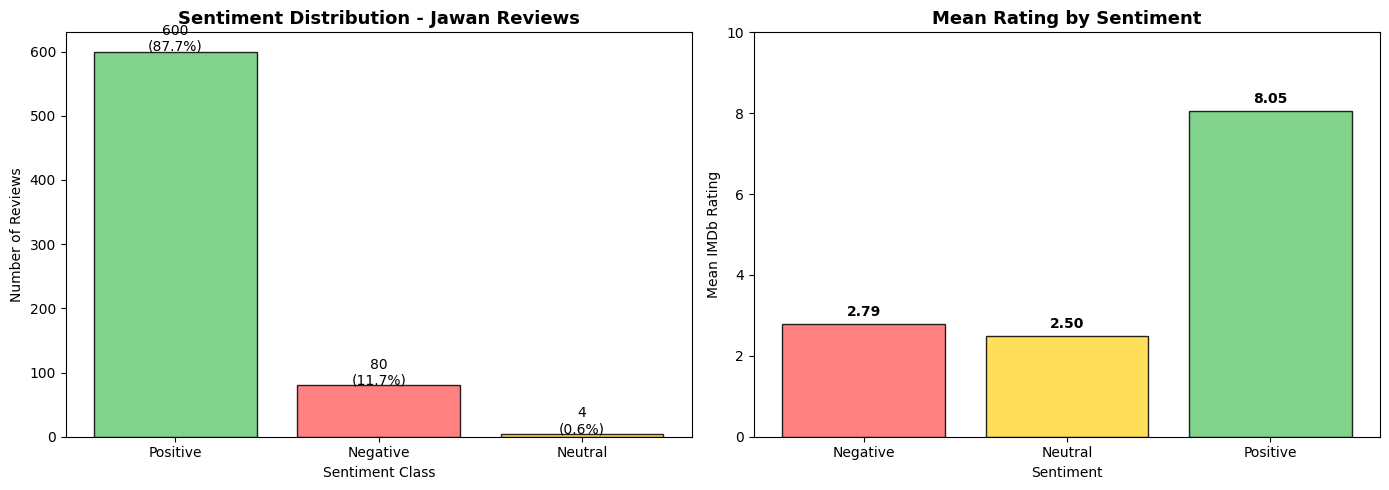

sentiment
Positive    600
Negative     80
Neutral       4
Name: count, dtype: int64

Mean rating per sentiment:
 sentiment
Negative    2.7875
Neutral     2.5000
Positive    8.0500
Name: rating, dtype: float64


In [ ]:
print("=== SENTIMENT DISTRIBUTION ANALYSIS ===")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sentiment_counts = df['sentiment'].value_counts()
bar_colors = {'Positive': '#6bcb77', 'Neutral': '#ffd93d', 'Negative': '#ff6b6b'}
bars = axes[0].bar(sentiment_counts.index,
                   sentiment_counts.values,
                   color=[bar_colors.get(s, 'gray') for s in sentiment_counts.index],
                   edgecolor='black', alpha=0.85)
axes[0].set_title('Sentiment Distribution - Jawan Reviews', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment Class')
axes[0].set_ylabel('Number of Reviews')
for bar, val in zip(bars, sentiment_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)

# Mean rating per sentiment
mean_rating_by_sent = df.groupby('sentiment')['rating'].mean()
axes[1].bar(mean_rating_by_sent.index, mean_rating_by_sent.values,
            color=[bar_colors.get(s, 'gray') for s in mean_rating_by_sent.index],
            edgecolor='black', alpha=0.85)
axes[1].set_title('Mean Rating by Sentiment', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Mean IMDb Rating')
axes[1].set_ylim(0, 10)
for i, (sent, val) in enumerate(mean_rating_by_sent.items()):
    axes[1].text(i, val + 0.2, f'{val:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(sentiment_counts)
print("\nMean rating per sentiment:\n", mean_rating_by_sent)

TOP POSITIVE THEMES:
  action               → 726
  story                → 380
  scene                → 367
  best                 → 297
  very                 → 264
  role                 → 262
  vijay                → 254
  character            → 251
  performance          → 241
  song                 → 221
  great                → 218
  audience             → 206
  music                → 201
  sequence             → 199
  message              → 191

TOP NEGATIVE THEMES:
  scene                → 55
  story                → 52
  action               → 52
  character            → 32
  song                 → 31
  plot                 → 31
  dont                 → 29
  indian               → 28
  money                → 27
  nothing              → 26
  vijay                → 25
  very                 → 24
  acting               → 24
  waste                → 24
  people               → 22


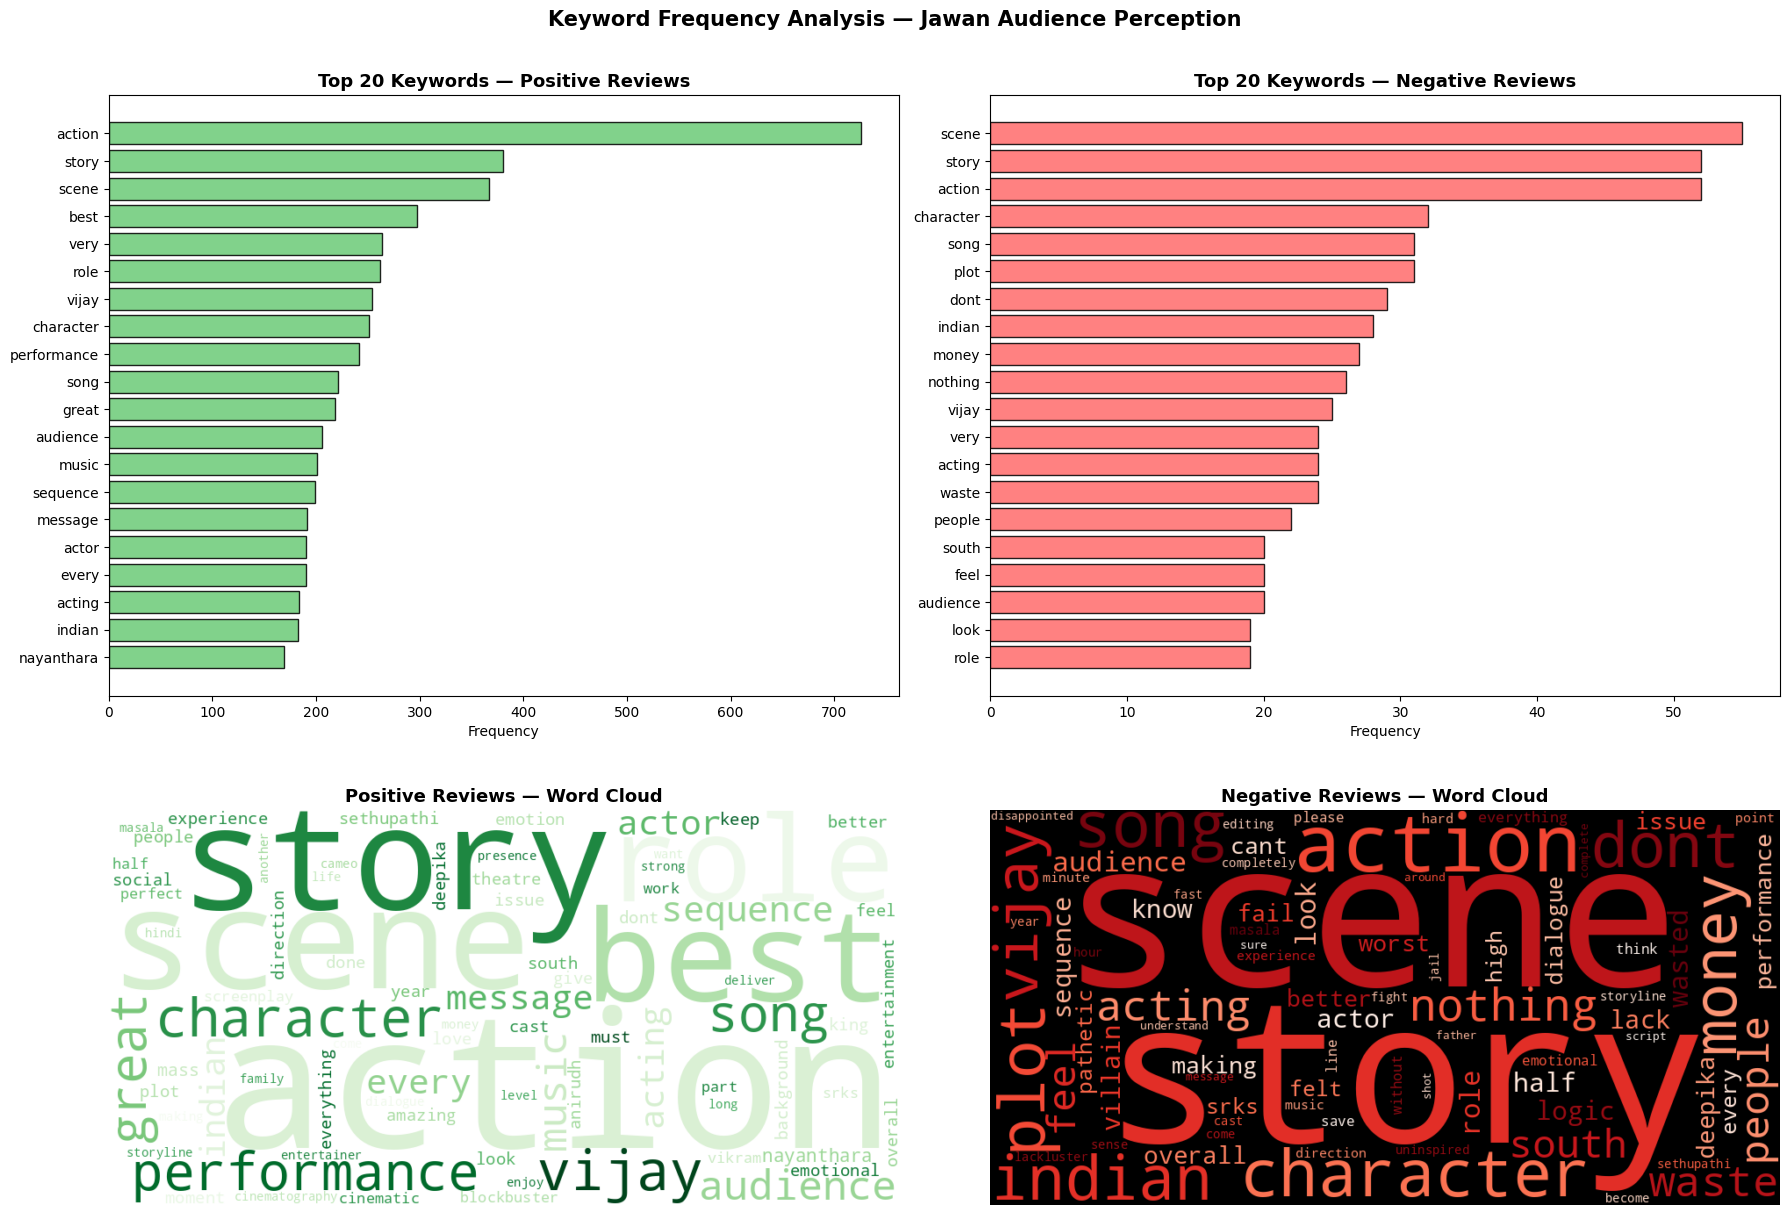

In [ ]:
# ============================================================
# CUSTOM DOMAIN STOPWORDS for Jawan movie analysis
# ============================================================
custom_stopwords = {
    # Movie/film generic
    'movie', 'film', 'cinema', 'watch', 'watched', 'watching',
    'see', 'seen', 'show', 'picture', 'screen',

    # Movie specific (Jawan context)
    'jawan', 'srk', 'shah', 'rukh', 'khan', 'shahrukh',
    'atlee', 'director', 'bollywood',

    # Generic filler words that slip past NLTK stopwords
    'one', 'also', 'even', 'much', 'well', 'really', 'like',
    'got', 'get', 'go', 'going', 'would', 'could', 'make',
    'made', 'way', 'time', 'good', 'bad', 'just', 'bit',
    'thing', 'lot', 'many', 'first', 'second', 'two',
    'never', 'ever', 'still', 'back',

    # Common review filler
    'imdb', 'review', 'reviewer', 'rating', 'rate', 'star', 'stars'
}

# ============================================================
# FUNCTION: Clean keyword list using custom stopwords
# ============================================================
def get_filtered_keywords(text_series, custom_sw, top_n=25):
    all_text = ' '.join(text_series.dropna())
    words = all_text.split()
    # Filter out custom stopwords AND short words
    filtered = [w for w in words if w not in custom_sw and len(w) > 3]
    return Counter(filtered).most_common(top_n)

# ============================================================
# Get filtered keywords by sentiment
# ============================================================
pos_reviews = df[df['sentiment'] == 'Positive']['cleaned_review']
neg_reviews = df[df['sentiment'] == 'Negative']['cleaned_review']
neu_reviews = df[df['sentiment'] == 'Neutral']['cleaned_review']

pos_keywords = get_filtered_keywords(pos_reviews, custom_stopwords, top_n=25)
neg_keywords = get_filtered_keywords(neg_reviews, custom_stopwords, top_n=25)

print("TOP POSITIVE THEMES:")
for word, count in pos_keywords[:15]:
    print(f"  {word:20s} → {count}")

print("\nTOP NEGATIVE THEMES:")
for word, count in neg_keywords[:15]:
    print(f"  {word:20s} → {count}")

# ============================================================
# VISUALIZATION
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 13))

# --- Positive Bar Chart ---
pos_df = pd.DataFrame(pos_keywords[:20], columns=['word', 'count'])
axes[0][0].barh(pos_df['word'][::-1], pos_df['count'][::-1],
                color='#6bcb77', edgecolor='black', alpha=0.85)
axes[0][0].set_title('Top 20 Keywords — Positive Reviews', fontsize=13, fontweight='bold')
axes[0][0].set_xlabel('Frequency')

# --- Negative Bar Chart ---
neg_df = pd.DataFrame(neg_keywords[:20], columns=['word', 'count'])
axes[0][1].barh(neg_df['word'][::-1], neg_df['count'][::-1],
                color='#ff6b6b', edgecolor='black', alpha=0.85)
axes[0][1].set_title('Top 20 Keywords — Negative Reviews', fontsize=13, fontweight='bold')
axes[0][1].set_xlabel('Frequency')

# --- Positive WordCloud ---
pos_text_filtered = ' '.join(
    [w for w in ' '.join(pos_reviews.dropna()).split()
     if w not in custom_stopwords and len(w) > 3]
)
wc_pos = WordCloud(width=900, height=450, background_color='white',
                   colormap='Greens', max_words=80,
                   collocations=False).generate(pos_text_filtered)
axes[1][0].imshow(wc_pos, interpolation='bilinear')
axes[1][0].axis('off')
axes[1][0].set_title('Positive Reviews — Word Cloud', fontsize=13, fontweight='bold')

# --- Negative WordCloud ---
neg_text_filtered = ' '.join(
    [w for w in ' '.join(neg_reviews.dropna()).split()
     if w not in custom_stopwords and len(w) > 3]
)
wc_neg = WordCloud(width=900, height=450, background_color='black',
                   colormap='Reds', max_words=80,
                   collocations=False).generate(neg_text_filtered)
axes[1][1].imshow(wc_neg, interpolation='bilinear')
axes[1][1].axis('off')
axes[1][1].set_title('Negative Reviews — Word Cloud', fontsize=13, fontweight='bold')

plt.suptitle('Keyword Frequency Analysis — Jawan Audience Perception',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('keyword_analysis_filtered.png', dpi=150, bbox_inches='tight')
plt.show()

=== SENTIMENT vs RATING RELATIONSHIP ===


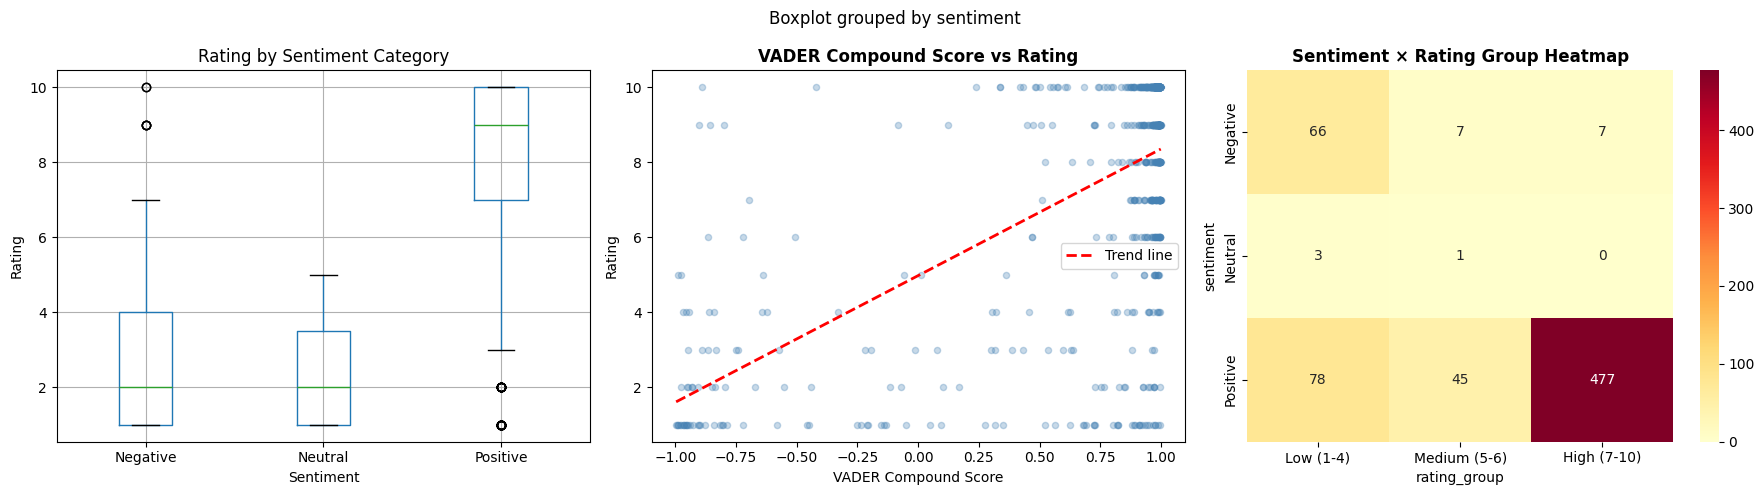


Correlation Matrix:
                 rating  vader_compound  tb_polarity
rating           1.000           0.599        0.649
vader_compound   0.599           1.000        0.587
tb_polarity      0.649           0.587        1.000


In [ ]:
print("=== SENTIMENT vs RATING RELATIONSHIP ===")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot
order = ['Negative', 'Neutral', 'Positive']
df_plot = df[df['sentiment'].isin(order)]
df_plot.boxplot(column='rating', by='sentiment', ax=axes[0])
axes[0].set_title('Rating by Sentiment Category', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Rating')
plt.sca(axes[0])
plt.title('Rating by Sentiment Category')

# Scatter: VADER compound vs rating
axes[1].scatter(df['vader_compound'], df['rating'], alpha=0.3, color='steelblue', s=20)
z = np.polyfit(df['vader_compound'].dropna(), df.loc[df['vader_compound'].notna(), 'rating'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['vader_compound'].min(), df['vader_compound'].max(), 100)
axes[1].plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Trend line')
axes[1].set_title('VADER Compound Score vs Rating', fontsize=12, fontweight='bold')
axes[1].set_xlabel('VADER Compound Score')
axes[1].set_ylabel('Rating')
axes[1].legend()

# Heatmap: sentiment group vs rating group
cross_tab = pd.crosstab(df['sentiment'], df['rating_group'])
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlOrRd', ax=axes[2])
axes[2].set_title('Sentiment × Rating Group Heatmap', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('sentiment_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation
corr = df[['rating', 'vader_compound', 'tb_polarity']].corr()
print("\nCorrelation Matrix:\n", corr.round(3))

=== REVIEW LENGTH vs RATING RELATIONSHIP ===


/tmp/ipykernel_523/269207527.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_by_bucket = df.groupby('wc_bucket')['rating'].mean()


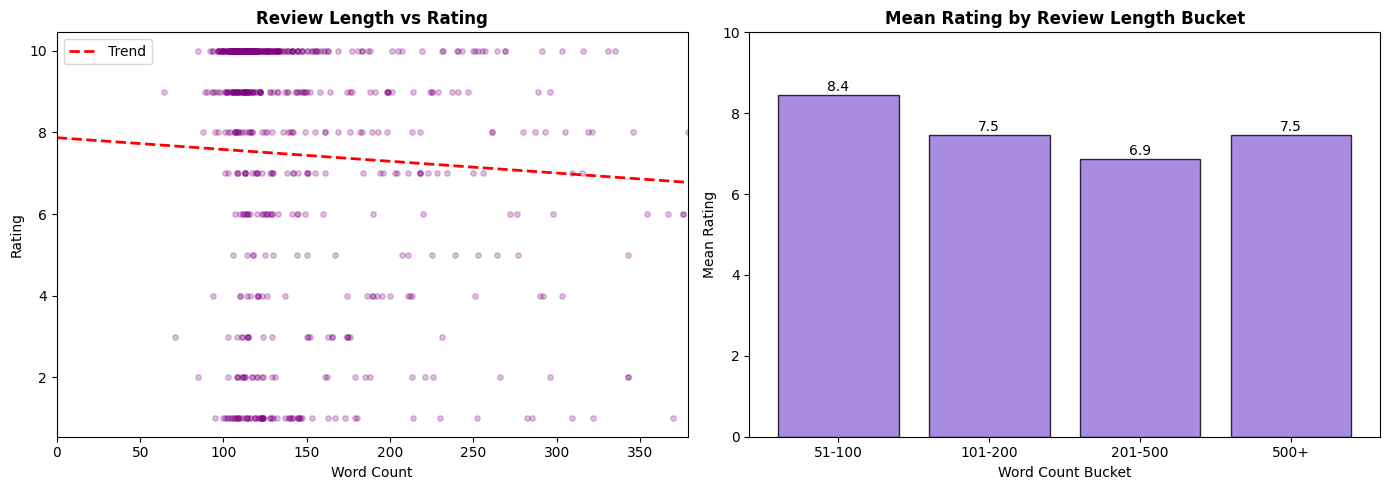


Correlation between Word Count and Rating:
             rating  word_count
rating       1.000      -0.086
word_count  -0.086       1.000


In [ ]:
print("=== REVIEW LENGTH vs RATING RELATIONSHIP ===")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter with trend
axes[0].scatter(df['word_count'], df['rating'], alpha=0.25, color='purple', s=15)
z = np.polyfit(df['word_count'].dropna(), df.loc[df['word_count'].notna(), 'rating'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, df['word_count'].quantile(0.95), 100)
axes[0].plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend')
axes[0].set_xlim(0, df['word_count'].quantile(0.95))
axes[0].set_title('Review Length vs Rating', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Rating')
axes[0].legend()

# Mean rating by word count bucket
df['wc_bucket'] = pd.cut(df['word_count'], bins=[0,25,50,100,200,500,2000],
                          labels=['1-25','26-50','51-100','101-200','201-500','500+'])
mean_by_bucket = df.groupby('wc_bucket')['rating'].mean()
axes[1].bar(mean_by_bucket.index, mean_by_bucket.values,
            color='mediumpurple', edgecolor='black', alpha=0.8)
axes[1].set_title('Mean Rating by Review Length Bucket', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Word Count Bucket')
axes[1].set_ylabel('Mean Rating')
axes[1].set_ylim(0, 10)
for i, v in enumerate(mean_by_bucket.values):
    axes[1].text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('length_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()

corr_len = df[['rating', 'word_count']].corr()
print("\nCorrelation between Word Count and Rating:\n", corr_len.round(3))

In [ ]:
print("=== OLS REGRESSION MODEL: PREDICTING RATING ===")

# Clean data for regression
reg_df = df[['rating', 'vader_compound', 'tb_subjectivity',
             'word_count', 'tb_polarity']].dropna()

# Rename for statsmodels formula compatibility
reg_df.columns = ['rating', 'vader_compound', 'tb_subjectivity',
                   'word_count', 'tb_polarity']

# Model 1: Simple (just sentiment)
model1 = smf.ols('rating ~ vader_compound', data=reg_df).fit()
print("\n--- MODEL 1: Simple Regression ---")
print(f"R² = {model1.rsquared:.4f}")
print(f"vader_compound coef = {model1.params['vader_compound']:.4f}, "
      f"p = {model1.pvalues['vader_compound']:.4f}")

# Model 2: Multiple Regression
formula = 'rating ~ vader_compound + tb_subjectivity + word_count + tb_polarity'
model2 = smf.ols(formula, data=reg_df).fit()

print("\n--- MODEL 2: Multiple Regression (Full Model) ---")
print(model2.summary())

# Save key results summary
print("\n=== KEY REGRESSION FINDINGS ===")
print(f"R-squared      : {model2.rsquared:.4f}")
print(f"Adj R-squared  : {model2.rsquared_adj:.4f}")
print(f"F-statistic    : {model2.fvalue:.4f}  (p = {model2.f_pvalue:.4f})")
print("\nCoefficients:")
for var in model2.params.index:
    sig = "***" if model2.pvalues[var] < 0.001 else \
          "**"  if model2.pvalues[var] < 0.01  else \
          "*"   if model2.pvalues[var] < 0.05  else ""
    print(f"  {var:25s}: β = {model2.params[var]:7.4f}  "
          f"(p = {model2.pvalues[var]:.4f}) {sig}")

=== OLS REGRESSION MODEL: PREDICTING RATING ===

--- MODEL 1: Simple Regression ---
R² = 0.3590
vader_compound coef = 3.3771, p = 0.0000

--- MODEL 2: Multiple Regression (Full Model) ---
                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.500
Model:                            OLS   Adj. R-squared:                  0.497
Method:                 Least Squares   F-statistic:                     169.8
Date:                Tue, 10 Mar 2026   Prob (F-statistic):          1.05e-100
Time:                        15:26:47   Log-Likelihood:                -1514.6
No. Observations:                 684   AIC:                             3039.
Df Residuals:                     679   BIC:                             3062.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      

In [ ]:
# Save the final analysis-ready dataframe
df.to_csv("jawan_final_analysis.csv", index=False)
print("✅ Saved: jawan_final_analysis.csv")

# Summary dashboard
print("\n" + "="*50)
print("ANALYSIS SUMMARY - JAWAN (IMDb Reviews)")
print("="*50)
print(f"Total Reviews Analyzed : {len(df)}")
print(f"Mean Rating            : {df['rating'].mean():.2f} / 10")
print(f"Positive Reviews       : {(df['sentiment']=='Positive').sum()} "
      f"({(df['sentiment']=='Positive').mean()*100:.1f}%)")
print(f"Negative Reviews       : {(df['sentiment']=='Negative').sum()} "
      f"({(df['sentiment']=='Negative').mean()*100:.1f}%)")
print(f"Neutral Reviews        : {(df['sentiment']=='Neutral').sum()} "
      f"({(df['sentiment']=='Neutral').mean()*100:.1f}%)")
print(f"Mean VADER Score       : {df['vader_compound'].mean():.4f}")
print(f"Mean Review Length     : {df['word_count'].mean():.0f} words")
print(f"Regression R²          : {model2.rsquared:.4f}")

✅ Saved: jawan_final_analysis.csv

ANALYSIS SUMMARY - JAWAN (IMDb Reviews)
Total Reviews Analyzed : 684
Mean Rating            : 7.40 / 10
Positive Reviews       : 600 (87.7%)
Negative Reviews       : 80 (11.7%)
Neutral Reviews        : 4 (0.6%)
Mean VADER Score       : 0.7185
Mean Review Length     : 162 words
Regression R²          : 0.5000
